# **Case Study 1 - William Armentrout**

## **Introduction:**
In recent years a large amount of attention has been spent on Billionairs with regards to their welth. Particularly with extra scrutiny looking into what can be specified as the 'tech billionairs' that are the forefront in investments in Artificual Intelligence.

This case study is looking into three crucial research questions regarding billionairs welth and potential correlations between them, their industries, and their country of origin.

- R1: Do billionaires in the technology industry have higher average new worth than those in other industries?
- R2: Is there a relationship between age and net worth among billionaires? 
- R3: Does the number of Billionaires per country correlate with GDP size? 

In [ ]:
# Import statements
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from scipy import stats

In [3]:
# Read data
df = pd.read_csv('Billionaires.csv')
#print(df.shape)
#df.head()


Before we get into evaluating the research questions we need a brief overview of the Billionaires.csv dataset. In order to best determine normality here is a histogram of billionairs across their networth in millions of dollars. I used both the raw scale and the log scale due to difference in mangitudes of wealth to capture the data better.

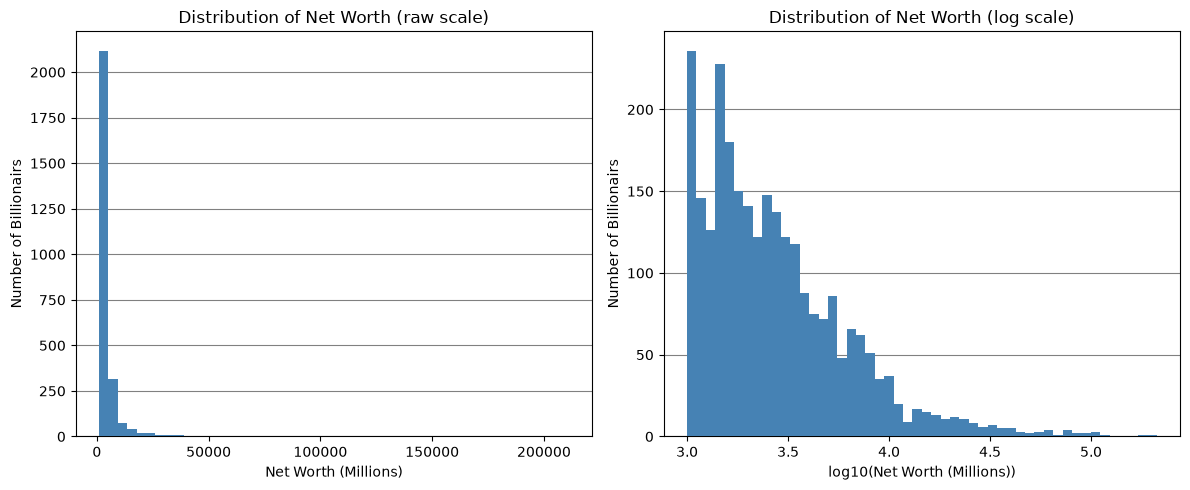

In [4]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

# raw data
axes[0].hist(df['finalWorth'], bins=50, color='steelblue', zorder=3)
axes[0].set_xlabel('Net Worth (Millions)')
axes[0].set_ylabel('Number of Billionairs')
axes[0].set_title('Distribution of Net Worth (raw scale)')
axes[0].yaxis.grid(True, color='gray')
axes[0].set_axisbelow(True)

# log scale
axes[1].hist(np.log10(df['finalWorth']), bins=50, color='steelblue', zorder=3)
axes[1].set_xlabel('log10(Net Worth (Millions))')
axes[1].set_ylabel('Number of Billionairs')
axes[1].set_title('Distribution of Net Worth (log scale)')
axes[1].yaxis.grid(True, color='gray')
axes[1].set_axisbelow(True)


plt.tight_layout()
plt.show()

As you can see in the histograms above the dataset of billionaires is heavily skewed. This will need to be taken into account in the methods used to evaluate the research questions.

## **Research Question 1:**
#### Do billionaires in the technology industry have higher average new worth than those in other industries?

**Method chosen:** Use mean/median and Welch's independent-samples t-test with a man-Whitney U test as a non-parametric check. This is needed as the  data is heavily skewed breaking the normailty assumption of the t-test.

In [5]:
tech  = df.loc[df['category']=='Technology', 'finalWorth']
other = df.loc[df['category']!='Technology', 'finalWorth']

print(f"Technology: n={len(tech)}, mean=${tech.mean():,.1f}M, median=${tech.median():,.1f}M")
print(f"Other:      n={len(other)}, mean=${other.mean():,.1f}M, median=${other.median():,.1f}M")

t_stat, p_val = stats.ttest_ind(tech, other, equal_var=False)
print(f"Welch's t-test: t={t_stat:.3f}, p={p_val:.4f}")

u_stat, p_mw = stats.mannwhitneyu(tech, other, alternative='two-sided')
print(f"Mann-Whitney U: U={u_stat:.1f}, p={p_mw:.4f}")

Technology: n=314, mean=$5,980.6M, median=$2,200.0M
Other:      n=2326, mean=$4,440.6M, median=$2,400.0M
Welch's t-test: t=1.891, p=0.0595
Mann-Whitney U: U=369392.5, p=0.7397


**Interpretation:** The mean is higher for tech, but the median is slightly lower than the other industries. Also neither the t or u test held any significance as both had p-values over 0.05. Both of these is likely due to extreme outliers such as Musk, Bezos, etc inflating the mean for the tech billionairs. This indicates that the tech billionairs are not wealthier than those in other industries.

**Visualization:**

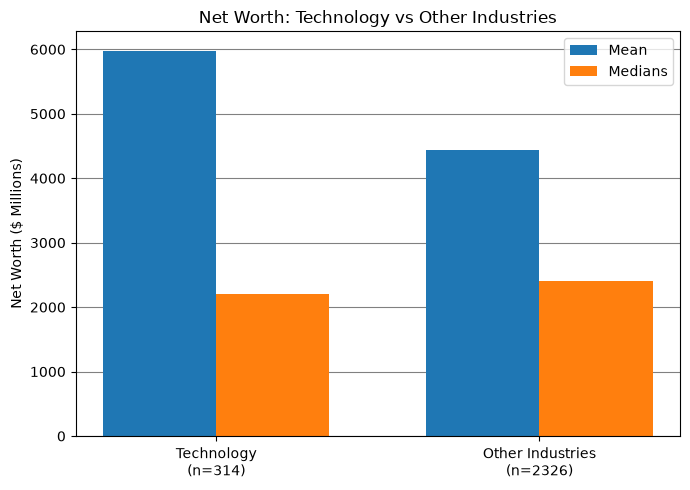

In [6]:
categories = ['Technology\n(n=314)', 'Other Industries\n(n=2326)']
means = [tech.mean(), other.mean()]
medians = [tech.median(), other.median()]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(x - width/2, means, width, label='Mean')
ax.bar(x + width/2, medians, width, label='Medians')

ax.set_ylabel('Net Worth ($ Millions)')
ax.set_title('Net Worth: Technology vs Other Industries')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.yaxis.grid(True, color='gray', linestyle='-')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## **Research Question 2:**

#### Is there a relationship between age and net worth among billionaires? 

**Method chosen:** Pearson and Spearman's correlation with a simple linear regression. Spearman is included as finalWorth is skewed. Spearmans is more resistent to outliers than Pearsons.

In [7]:
sub = df[['age', 'finalWorth']].dropna()

pearson_r, pearson_p = stats.pearsonr(sub['age'], sub['finalWorth'])
spearman_r, spearman_p = stats.spearmanr(sub['age'], sub['finalWorth'])
slope, intercept, r_value, p_value, std_err = stats.linregress(sub['age'], sub['finalWorth'])

print(f"Pearson r = {pearson_r:.4f}, p = {pearson_p:.4f}")
print(f"Spearman rho = {spearman_r:.4f}, p = {spearman_p:.4f}")
print(f"Regression: slope={slope:.2f}, R^2 = {r_value**2:.4f}, p = {p_value:.4f}")

Pearson r = 0.0671, p = 0.0007
Spearman rho = 0.1440, p = 0.0000
Regression: slope=50.28, R^2 = 0.0045, p = 0.0007


**Interpretation:**

**Visualization:**

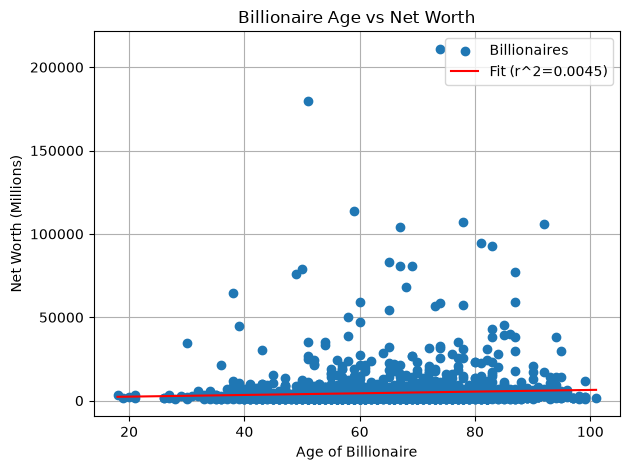

In [18]:
age_range = np.arange(df['age'].min(),df['age'].max()+1)

fig, ax = plt.subplots()

ax.scatter(x='age',y='finalWorth', data=df, label='Billionaires')
ax.plot(age_range, slope*age_range + intercept, color='red', label=f'Fit (r^2={r_value**2:.4f})')

ax.set_title('Billionaire Age vs Net Worth')
ax.set_xlabel('Age of Billionaire')
ax.set_ylabel('Net Worth (Millions)')
ax.grid()
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()

## Research Question 3:

#### Does the number of Billionaires per country correlate with GDP size? 

**Method chosen:** Country level aggregation, then Pearson correlation used on both the raw and log-log since both GDP and billionair counts span orders of magnitude across countries.

In [30]:
df['gdp_clean'] = df['gdp_country'].replace(r'[\$,]', '', regex=True).astype(float)

counts = df.groupby('country').size().rename('billionaire_count')
gdp = df.groupby('country')['gdp_clean'].mean().rename('gdp')
merged = pd.concat([counts, gdp], axis=1).dropna()

pearson_r, pearson_p = stats.pearsonr(merged['billionaire_count'], merged['gdp'])
print(f"Pearson r = {pearson_r:.4f}, p = {pearson_p:.4f}")


log_pearson_r, log_pearson_p = stats.pearsonr(np.log(merged['billionaire_count']), np.log(merged['gdp']))
print(f"Pearson r (log-log) = {log_pearson_r:.4f}, p = {log_pearson_p:.4f}")

slope, intercept, r_value, p_value, std_err = stats.linregress(merged['billionaire_count'], merged['gdp'])
print(f"Regression: slope={slope:.2f}, R^2 = {r_value**2:.4f}, p = {p_value:.4f}")

log_slope, log_intercept, log_r_value, log_p_value, log_std_err = stats.linregress(np.log(merged['billionaire_count']), np.log(merged['gdp']))
print(f"Regression (log-log): slope={log_slope:.2f}, R^2 = {log_r_value**2:.4f}, p = {log_p_value:.4f}")

Pearson r = 0.9702, p = 0.0000
Pearson r (log-log) = 0.8200, p = 0.0000
Regression: slope=30913831052.91, R^2 = 0.9412, p = 0.0000
Regression (log-log): slope=0.86, R^2 = 0.6724, p = 0.0000


**Interpretation:**

**Visualization:**

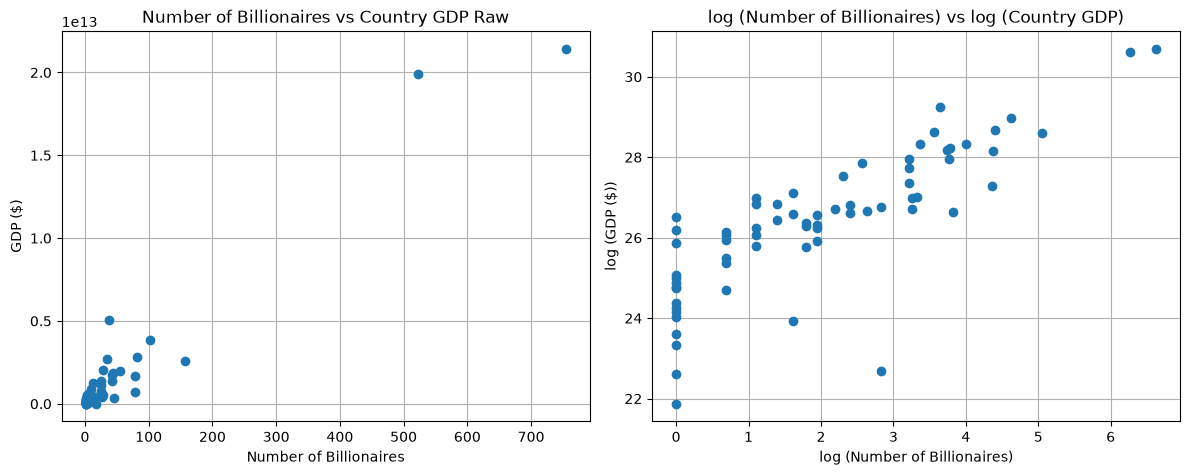

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].scatter(x='billionaire_count', y='gdp', data=merged)
ax[0].plot()
ax[0].set_title('Number of Billionaires vs Country GDP Raw')
ax[0].set_xlabel('Number of Billionaires')
ax[0].set_ylabel('GDP ($)')
ax[0].grid()
ax[0].set_axisbelow(True)

ax[1].scatter(np.log(merged['billionaire_count']), np.log(merged['gdp']))
ax[1].set_title('log (Number of Billionaires) vs log (Country GDP)')
ax[1].set_xlabel('log (Number of Billionaires)')
ax[1].set_ylabel('log (GDP ($))')
ax[1].grid()
ax[1].set_axisbelow(True)

plt.tight_layout()
plt.show()